# Ejercicio 3 - Práctica 4

El dataset `Penguins` contiene información acerca de un conjunto de pingüinos que habitan el Archipiélago Palmer, un archipiélago del Océano Glacial Antártico que se encuentra conformado por un conjunto de islas montañosas. Sobre cada ejemplar se cuenta con la siguiente información:

`species`: especie a la que pertenece (Chinstrap, Adélie o Gentoo).

`culmen_length_mm`: largo del culmen, cresta superior del pico (mm).

`culmen_depth_mm`: altura del culmen (mm).

`flipper_length_mm`: largo de la aleta (mm).

`body_mass_g`: masa corporal (g).

`island`: nombre de la isla del Archipiélago Palmer en la que habita (Dream, Torgersen o Biscoe).

`sex`: sexo.

El mismo puede importarse al entorno de trabajo utilizando la función `sns.load_dataset('penguins')` de Seaborn.

1. Reproduzca el gráfico mostrado en la siguiente figura para visualizar la distribución del largo de la aleta entre las distintas especies de pingüinos. En el mismo se utilizaron colores pertenecientes a la paleta magma.

![Imagen 1](../img/5172a9e7cfc2293725e2b6db1837cbd3c90fcefc5e5dd4fbcf46bc32a47acef2.png)

2. Realice una tabla en la que se muestre qué porcentaje de pingüinos del dataset pertenece a cada una de las tres especies.

3. Teniendo en cuenta las características del gráfico realizado en el ítem 1 y la información contenida en la tabla realizada en el ítem 2, ¿qué observación puede realizar acerca de las curvas de densidad representadas para cada especie? Sugerencia: dentro de la documentación de Seaborn, busque información sobre el parámetro common_norm de la función `kdeplot()` que utilizó para construir el gráfico.

4. ¿A cuál de las tres especies se refiere la siguiente frase? El 90% de los pingüinos presenta una longitud de aleta menor o igual a 198 mm.

In [2]:
# Importamos los paquetes necesarios

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Item 1

 Reproduzca el gráfico mostrado en la siguiente figura para visualizar la distribución del largo de la aleta entre las distintas especies de pingüinos. En el mismo se utilizaron colores pertenecientes a la paleta magma.

In [9]:
# Cargamos el df
df = sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


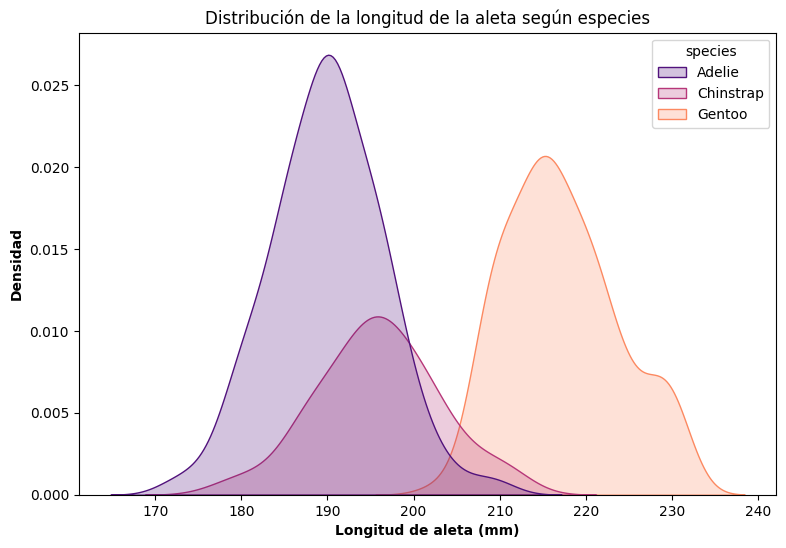

In [16]:
plt.figure(figsize = (9, 6))

sns.kdeplot(x = 'flipper_length_mm', hue = 'species',
            multiple = 'layer', fill = True, 
            palette = 'magma', data = df)

plt.xlabel('Longitud de aleta (mm)', fontweight = 'bold')
plt.ylabel('Densidad', fontweight = 'bold')
plt.title('Distribución de la longitud de la aleta según especies')

plt.show()

# Item 2

Realice una tabla en la que se muestre qué porcentaje de pingüinos del dataset pertenece a cada una de las tres especies.

In [15]:
df['species'].value_counts(normalize = True).mul(100).round(2)

species
Adelie       44.19
Gentoo       36.05
Chinstrap    19.77
Name: proportion, dtype: float64

# Item 3

Teniendo en cuenta las características del gráfico realizado en el ítem 1 y la información contenida en la tabla realizada en el ítem 2, ¿qué observación puede realizar acerca de las curvas de densidad representadas para cada especie? Sugerencia: dentro de la documentación de Seaborn, busque información sobre el parámetro `common_norm` de la función `kdeplot()` que utilizó para construir el gráfico.

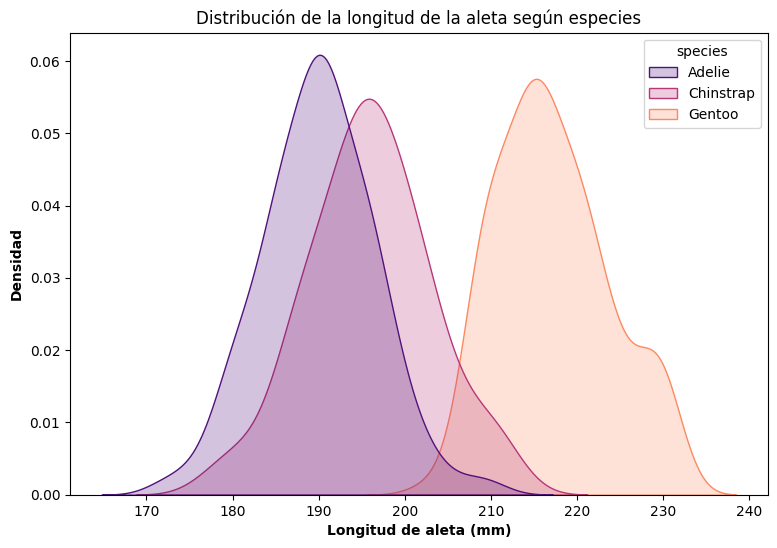

In [17]:
plt.figure(figsize = (9, 6))

sns.kdeplot(x = 'flipper_length_mm', hue = 'species',
            multiple = 'layer', fill = True, 
            palette = 'magma', data = df, common_norm= False)

plt.xlabel('Longitud de aleta (mm)', fontweight = 'bold')
plt.ylabel('Densidad', fontweight = 'bold')
plt.title('Distribución de la longitud de la aleta según especies')

plt.show()

Las curvas están afectadas por el tamaño de muestra de cada especie, por lo que su comparación directa puede ser engañosa.

# Item 4

¿A cuál de las tres especies se refiere la siguiente frase? El 90% de los pingüinos presenta una longitud de aleta menor o igual a 198 mm.

In [21]:
df.groupby('species')['flipper_length_mm'].quantile(0.9)

# Concluimos que serefier a Adelie

species
Adelie       198.0
Chinstrap    205.0
Gentoo       228.0
Name: flipper_length_mm, dtype: float64